In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import astropy.constants as c

import aux_functions as aux
import dsharp_opac as opacity

Text(0, 0.5, '$\\kappa_p$ [cm$^2$ g$^{-1}$]')

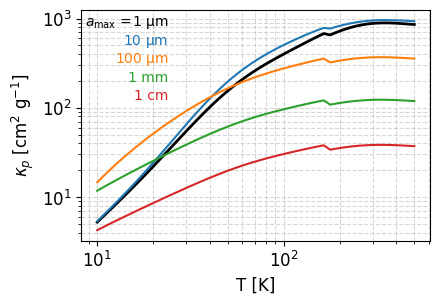

In [2]:

    plt.rc("font", size=12)
    plt.figure(figsize=(4.5,3))
    # load default opacities
    with np.load(opacity.get_datafile('default_opacities_smooth.npz')) as d:
        a_w     = d['a']
        gsca_w  = d['g']
        lam_w   = d['lam']
        k_abs_w = d['k_abs']
        k_sca_w = d['k_sca']
        rho_s   = d['rho_s']
        k_ext_w = k_abs_w + (1 - gsca_w) * k_sca_w

    with np.load(opacity.get_datafile('icefree_opacities_smooth.npz')) as d:
        a_d      = d['a']
        gsca_d   = d['g']
        lam_d    = d['lam']
        k_abs_d  = d['k_abs']
        k_sca_d  = d['k_sca']
        k_ext_d = k_abs_d + (1 - gsca_d) * k_sca_d

    if not np.allclose(a_w, a_d):
        raise RuntimeError('size grids in opacity data do not match')

    a = a_w
    lam = lam_w
    nu = c.c.cgs.value / lam

    # default temperature grid
    
    T_grid = np.logspace(np.log10(10.0), np.log10(500.0), 50)
    k_P_pf   = np.zeros((T_grid.shape[0], 5))
    k_R_pf   = np.zeros((T_grid.shape[0], 5))

    # size distribution: power-law n(a) ~ a^{-q}, mass weighting -> a^(4-q)
    q = 3.5
    for ita, amax in enumerate([1e-1 * 1e-3, 1e-1 * 1e-2, 1e-1 * 1e-1, 1e-1, 1]):  # cm
        power_law = a**(4.0 - q)
        power_law[a > amax] = 0.0
        power_law = power_law / power_law.sum()


        k_abs_p_w = (k_abs_w.T * power_law[None, :]).sum(1)
        k_ext_p_w = (k_ext_w.T * power_law[None, :]).sum(1)

        # the dry ones

        k_abs_p_d = (k_abs_d.T * power_law[None, :]).sum(1)
        k_ext_p_d = (k_ext_d.T * power_law[None, :]).sum(1)

        for it, _T in enumerate(T_grid):
            Bnu    = aux.planck_B_nu(nu, _T)
            dBnudT = aux.planck_dBnu_dT(nu, _T)
            B      = np.trapezoid(Bnu, x=nu)
            dBdT   = np.trapezoid(dBnudT, x=nu)

            if _T < 170:
                k_P_pf[it, ita]  = np.trapezoid(Bnu * k_abs_p_w, x=nu) / B
                k_R_pf[it, ita]  = dBdT / np.trapezoid(dBnudT / k_ext_p_w, x=nu)
            else:
                k_P_pf[it, ita]  = np.trapezoid(Bnu * k_abs_p_d, x=nu) / B
                k_R_pf[it, ita]  = dBdT / np.trapezoid(dBnudT / k_ext_p_d, x=nu)


        if ita == 0:
            plt.plot(T_grid, k_P_pf[:,ita], 'k-', linewidth=2)
            plt.text(0.01, 0.93-ita*0.08, r'$a_{\rm max}$ =', fontsize=10,
                  transform=plt.gca().transAxes)
        else:
            plt.plot(T_grid, k_P_pf[:,ita], )
        plt.text(0.25, 0.93-ita*0.08,  [r'1 $\rm \mu m$',
                                                            r'10 $\rm \mu m$',
                                                            r'100 $\rm \mu m$',
                                                            '1 mm', 
                                                            '1 cm', ][ita], fontsize=10,
                    ha='right',
                  transform=plt.gca().transAxes,
                  color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][ita])
    plt.loglog()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.xlabel("T [K]")
    plt.ylabel(r"$\kappa_p$ [cm$^2$ g$^{-1}$]")
    #plt.savefig("kappa_p.pdf", bbox_inches='tight', transparent=True)

In [3]:
mu = 2.3
T = T_grid
v_th = (8. * c.k_B.cgs.value * T / (np.pi*mu*c.m_p.cgs.value))**0.5

In [14]:
r_au = 50. # au
Omega_K = (c.G.cgs.value*c.M_sun.cgs.value / (r_au *c.au.cgs.value)**3)**0.5

Sigma_g = 10.0  # g/cm2
c_s = (c.k_B.cgs.value * T / (mu * c.m_p.cgs.value))**0.5
rho_g0 =  Sigma_g * Omega_K/ (np.sqrt(2*np.pi) * c_s)

z = 0. * c_s / Omega_K 
rhogz = rho_g0 * np.exp(-0.5 * (z * Omega_K / c_s)**2)

amax = np.array([1e-1 * 1e-3, 1e-1 * 1e-2, 1e-1 * 1e-1, 1e-1, 1])
t_s = rho_s * amax[None,:] / (rhogz[:,None] * v_th[:,None])
St = t_s * Omega_K

In [15]:
c_s.shape

(50,)

In [20]:

Sigma_d = 0.01  * Sigma_g
alpha = 1e-4
psi = np.sqrt(alpha/St)
settling_factor = (1 + psi**-2)**-0.5

rho_d0 = Sigma_d * Omega_K/ (np.sqrt(2*np.pi) * c_s[:, None] * settling_factor)
rhodz =  rho_d0 * np.exp(-0.5 * (z[:, None] * Omega_K / c_s[:, None]  / settling_factor)**2)
rhodz = (1./settling_factor) * rho_d0 * np.exp(-0.5 * (z[:, None] * Omega_K / c_s[:, None]/ settling_factor)**2)
# z dependent

In [21]:
settling_factor[0]

array([0.88975854, 0.52475391, 0.19133643, 0.06152802, 0.0194901 ])

In [22]:
rhodz[0]/rhogz[0]

array([1.26315217e-02, 3.63152166e-02, 2.73152166e-01, 2.64152166e+00,
       2.63252166e+01])

In [109]:
c_d = 10 * T**3
c_v = 2.5*c.k_B.cgs.value / (mu * c.m_p.cgs.value)
t_rad_d = c_d[:,None]/(16 * c.sigma_sb.cgs.value * k_P_pf * T[:,None]**3)
t_col_d = (2./3.)/(1.4-1) * c_d[:,None]/c_v * t_s

t_rad_g = (c_v/c_d[:,None])*(rhogz[:,None]/rhodz) * t_rad_d
t_col_g = (c_v/c_d[:,None])*(rhogz[:,None]/rhodz) * t_col_d



In [110]:
beta_rad_d = t_rad_d * Omega_K
beta_col_d = t_col_d * Omega_K
beta_rad_g = t_rad_g * Omega_K
beta_col_g = t_col_g * Omega_K


In [111]:
tau_IR = k_P_pf * Sigma_d / 2.0
t_diff_d = 0.3 * r_au * c.au.cgs.value /c.c.cgs.value * np.maximum(1, tau_IR)
beta_t_diff_d = t_diff_d * Omega_K

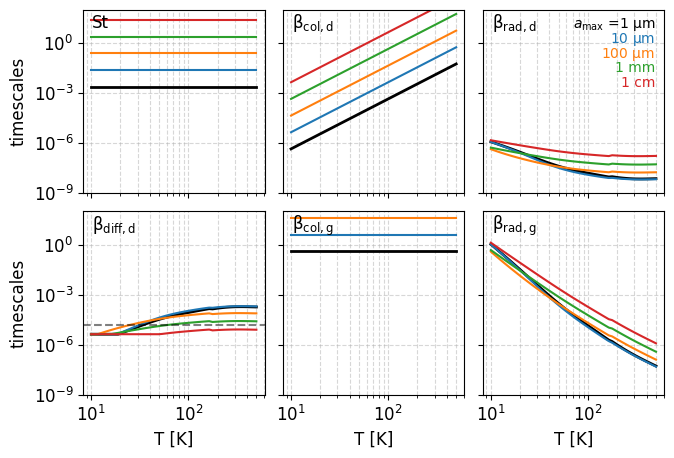

In [113]:
plt.rc("font", size=12)
plt.figure(figsize=(7.5,5))
colors = ['k', 'C0', 'C1', 'C2', 'C3', 'C4']
plt.subplot(2,3, 1)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, St[:,i], color=colors[i], linewidth=2)
    else:
        plt.plot(T, St[:,i], color=colors[i])
plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, 'St', transform=plt.gca().transAxes)
plt.tick_params(labelbottom=False)
plt.ylabel("timescales")

plt.subplot(2,3, 2)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, beta_col_d[:,i], color=colors[i], linewidth=2)
    else:
        plt.plot(T, beta_col_d[:,i], color=colors[i])
plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, r'$\rm \beta_{col,d}$', transform=plt.gca().transAxes)
plt.tick_params(labelbottom=False, labelleft=False)

plt.subplot(2,3, 3)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, beta_rad_d[:,i], color=colors[i], linewidth=2)
        plt.text(0.5, 0.9-i*0.08, r'$a_{\rm max}$ =', fontsize=10,
                  transform=plt.gca().transAxes)
    else:
        plt.plot(T, beta_rad_d[:,i], color=colors[i])

    plt.text(0.95, 0.9-i*0.08,  [r'1 $\rm \mu m$',
                                                            r'10 $\rm \mu m$',
                                                            r'100 $\rm \mu m$',
                                                            '1 mm', 
                                                            '1 cm', ][i], fontsize=10,
                    ha='right',
                  transform=plt.gca().transAxes,
                  color=colors[i])


plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, r'$\rm \beta_{rad,d}$', transform=plt.gca().transAxes)
plt.tick_params(labelbottom=False, labelleft=False)


plt.subplot(2,3, 4)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, beta_t_diff_d[:,i], color=colors[i], linewidth=2)
    else:
        plt.plot(T, beta_t_diff_d[:,i], color=colors[i])
plt.axhline(r_au*c.au.cgs.value/c.c.cgs.value*Omega_K, color='k', ls='--', alpha=0.5)
plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, r'$\rm \beta_{diff,d}$', transform=plt.gca().transAxes)
plt.xlabel("T [K]")
plt.ylabel("timescales")

plt.subplot(2,3, 5)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, beta_col_g[:,i], color=colors[i], linewidth=2)
    else:
        plt.plot(T, beta_col_g[:,i], color=colors[i])
plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, r'$\rm \beta_{col,g}$', transform=plt.gca().transAxes)
plt.tick_params(labelleft=False)
plt.xlabel("T [K]")

plt.subplot(2,3, 6)
for i in range(amax.shape[0]):
    if i == 0:
        plt.plot(T, beta_rad_g[:,i], color=colors[i], linewidth=2)
    else:
        plt.plot(T, beta_rad_g[:,i], color=colors[i])
plt.loglog()
plt.ylim(1e-9, 1e2)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.text(0.05, 0.9, r'$\rm \beta_{rad,g}$', transform=plt.gca().transAxes)
plt.tick_params(labelleft=False)
plt.xlabel("T [K]")
plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig("timescales_50au_sigmag10_3Hg_nosettling.pdf", bbox_inches='tight', transparent=True)

Text(0, 0.5, 'Dimensionless timescales')

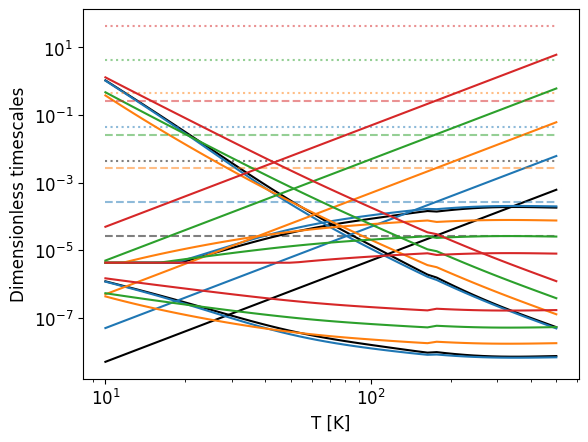

In [75]:
for i in range(5):
    plt.plot(T, St[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i], linestyle='--', alpha=0.5)

    plt.plot(T, beta_rad_d[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])
    plt.plot(T, beta_col_d[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])

    plt.plot(T, beta_rad_g[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])
    plt.plot(T, beta_col_g[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i], linestyle=':', alpha=0.5)
    plt.plot(T, beta_t_diff_d[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i],)

plt.loglog()
plt.xlabel("T [K]")
plt.ylabel("Dimensionless timescales")

Text(0, 0.5, 'Dimensionless timescales')

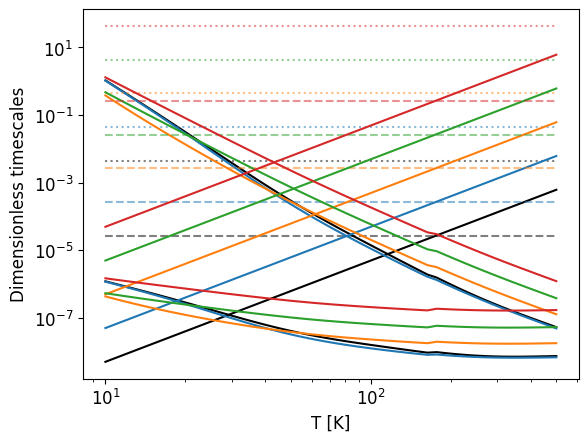

In [43]:
for i in range(5):
    plt.plot(T, St[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i], linestyle='--', alpha=0.5)

    plt.plot(T, beta_rad_d[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])
    plt.plot(T, beta_col_d[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])

    plt.plot(T, beta_rad_g[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i])
    plt.plot(T, beta_col_g[:,i], color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][i], linestyle=':', alpha=0.5)

plt.loglog()
plt.xlabel("T [K]")
plt.ylabel("Dimensionless timescales")

In [68]:
print(beta_rad_g)
print(beta_col_g)

0.00445521462488509
0.4385869432135598


In [77]:
np.sqrt(1e-4/1e-3)

np.float64(0.31622776601683794)

In [78]:
(1 + np.sqrt(1e-4/1e-2)**-2)**-0.5

np.float64(0.09950371902099892)

In [ ]:
# need to include alpha_z and alpha_r??